# 🩺 Student Health Condition Prediction

## Problem Statement

The goal is to predict a student's health condition (At-Risk, Fit, or Unhealthy) using lifestyle and physiological data.

## Dataset

- Kaggle Playground Series S6E7
- Training Samples: 690,088
- Test Samples: 295,753
- Target Variable: Health Condition

## Workflow

1. Data Loading
2. Exploratory Data Analysis
3. Feature Engineering
4. Preprocessing
5. Model Training
6. Hyperparameter Tuning
7. Final Model Selection
8. Model Deployment

# 1. Import Library and Dataset

In [1]:
# Import Library
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, balanced_accuracy_score

/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
train = pd.read_csv("/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/data/train.csv")
test = pd.read_csv("/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/data/test.csv")

# 2. Exploratory Data Analysis

## Dataset overview

###
- Total Records: 690,088
- Features: 14 (before feature engineering)
- Target Variable: health_condition
- Problem Type: Multi-Class Classification
- Classes:
    - at-risk
    - fit
    - unhealthy

In [3]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [4]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [5]:
# shape of dataset
print("train data shape: ",train.shape)
print("test data shape: ",test.shape)

train data shape:  (690088, 15)
test data shape:  (295753, 14)


## Missing value

In [6]:
# train dataset missing value
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [7]:
# test dataset missing value
test.isnull().sum()

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64

## Target Variable 

### Observation

The dataset is highly imbalanced.

- at-risk is the majority class.
- fit is the minority class.

Because of this imbalance, Balanced Accuracy was selected as the primary evaluation metric instead of overall accuracy.

In [8]:
train['health_condition'].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

## Numerical Feature Analysis

In [9]:
num_cols = train.select_dtypes(include=np.number).columns
num_cols = num_cols[1:]
print(num_cols)

Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='object')


### Summary Statistics

In [10]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


### Histogram Analysis

• Most numerical features follow an approximately normal or moderately skewed distribution.

• Features such as Sleep Duration, Heart Rate, and BMI are well distributed without significant abnormalities.

• No extreme distribution shifts were observed, making the dataset suitable for tree-based machine learning algorithms.

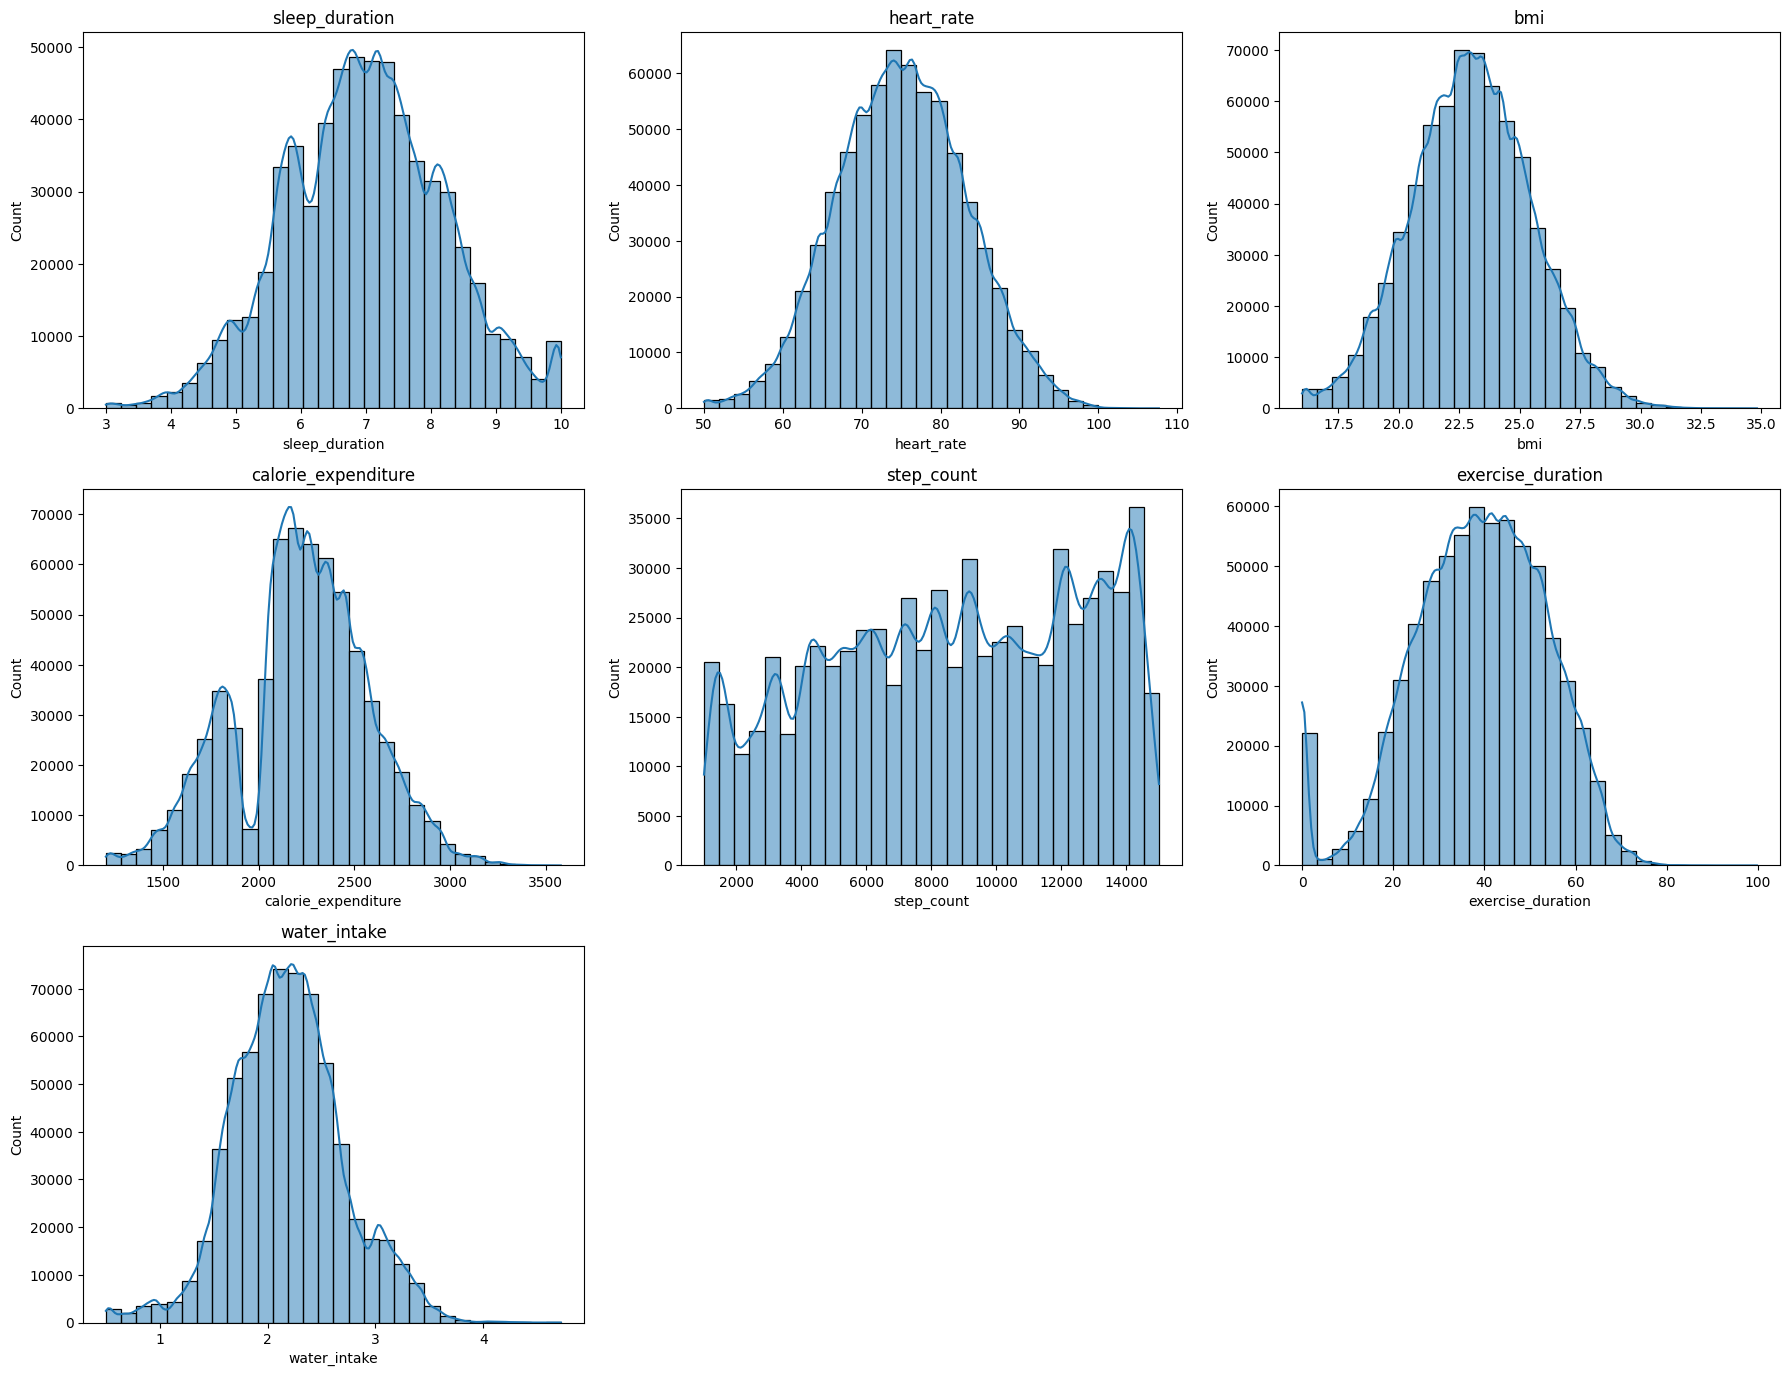

In [11]:
plt.figure(figsize=(18, 18))

for i, col in enumerate(num_cols):

    plt.subplot(4, 3, i + 1)
    sns.histplot(train[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()

plt.show()

### Boxplot Analysis/Outlier Analysis

• A few numerical features contain outliers.

• Since the final model is XGBoost, outlier removal was not performed because tree-based models are generally robust to outliers.

• Keeping these observations helps preserve potentially useful information.

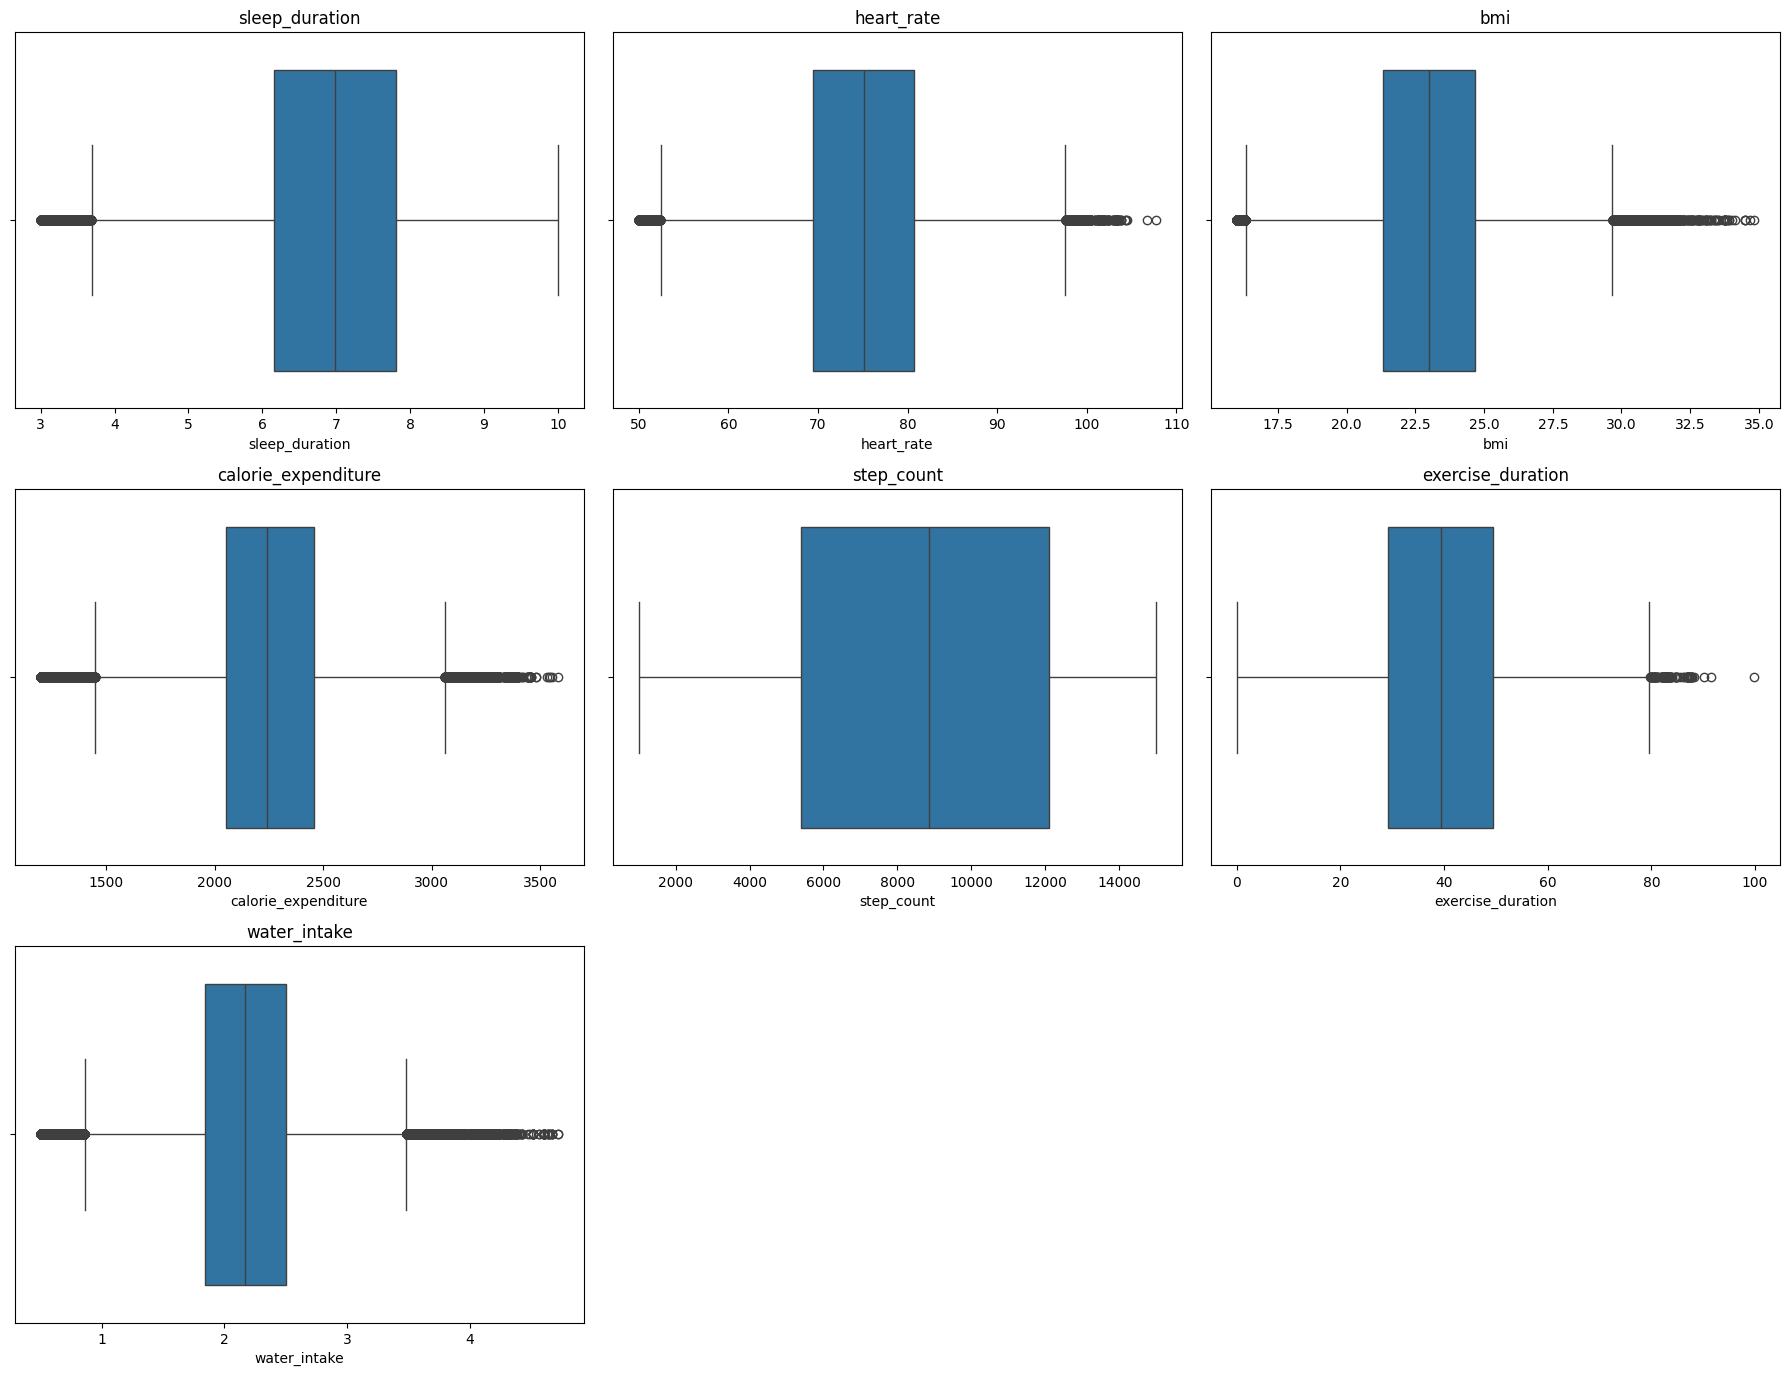

In [12]:
plt.figure(figsize=(18, 18))

for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(x=train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Skewness Analysis

• Most numerical variables exhibit low skewness.

• Mild skewness is acceptable for gradient boosting algorithms.

• Therefore, no logarithmic or power transformations were applied.

In [13]:
skewness = train[num_cols].skew()

skew_df = skewness.reset_index()
skew_df.columns = ["Feature", "Skewness"]

skew_df

,Feature,Skewness
0,sleep_duration,-0.008232
1,heart_rate,0.000438
2,bmi,0.024640
3,calorie_expenditure,-0.183940
4,step_count,-0.180238
5,exercise_duration,-0.374610
6,water_intake,0.109960


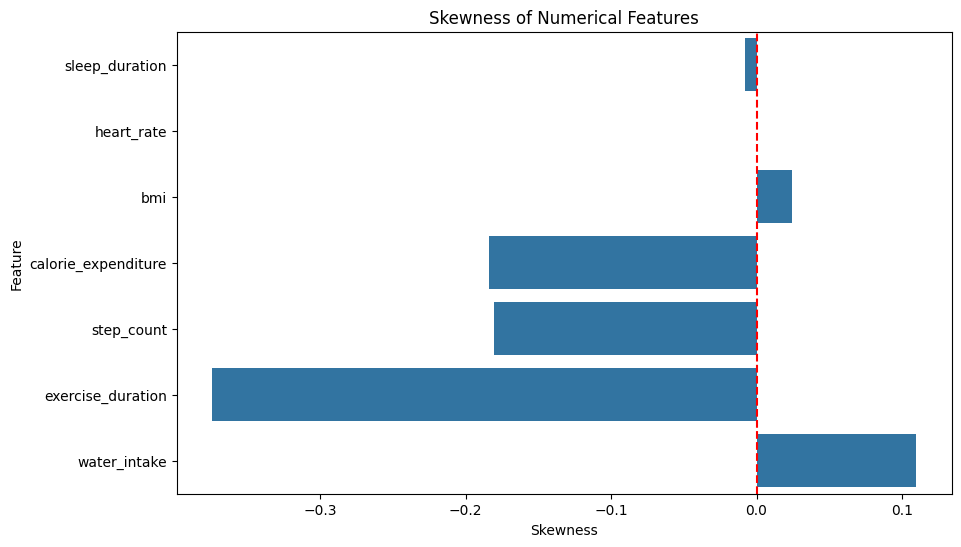

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=skew_df,
    x="Skewness",
    y="Feature"
)

plt.axvline(0, color="red", linestyle="--")

plt.title("Skewness of Numerical Features")

plt.show()

### Correlation Heatmap

• Most numerical features exhibit weak to moderate correlation.

• No severe multicollinearity was observed.

• Therefore, all numerical features were retained for model training.

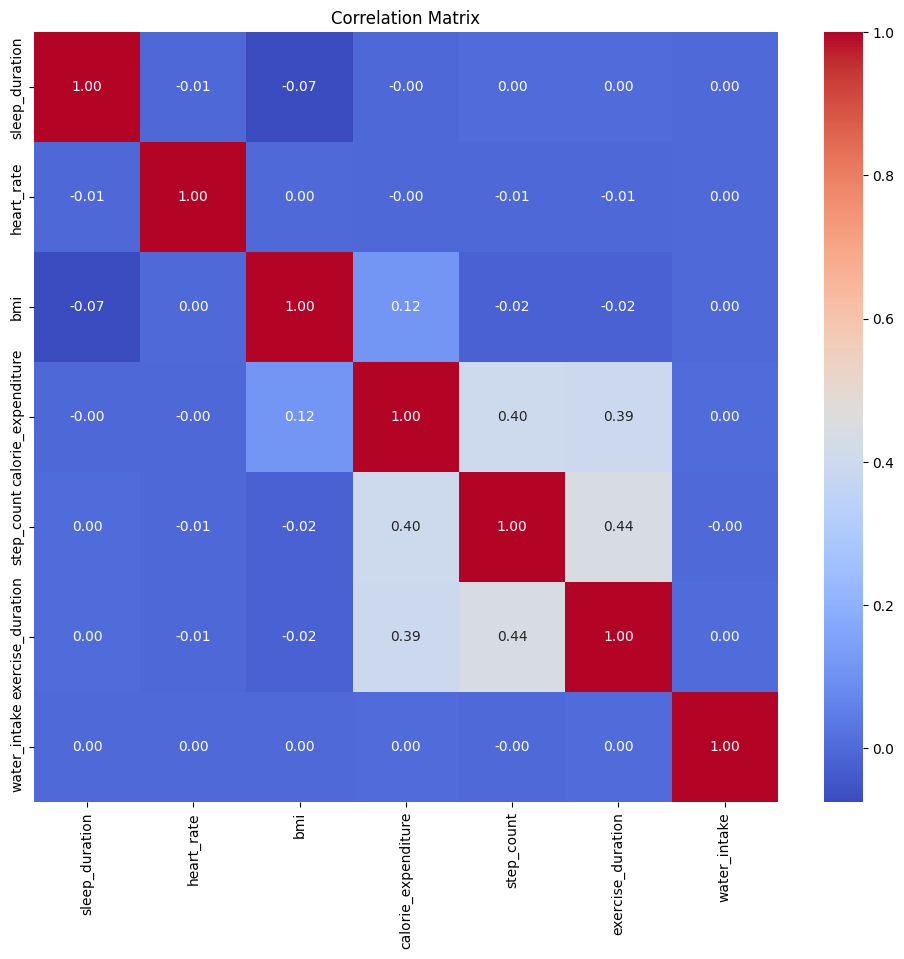

In [15]:
plt.figure(figsize=(12,10))

sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Categorical Fearure Analysis

In [16]:
cat_col = train.select_dtypes(include='object').columns
print(cat_col)

Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')


### Value Counts

In [17]:
for col in cat_col:
    print(f"\n{col}")
    print(train[col].value_counts())


health_condition
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

diet_type
diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64

stress_level
stress_level
medium    261819
high      177750
low       167708
Name: count, dtype: int64

sleep_quality
sleep_quality
average    213948
poor       212166
good       205643
Name: count, dtype: int64

physical_activity_level
physical_activity_level
moderate     221041
sedentary    219784
active       212642
Name: count, dtype: int64

smoking_alcohol
smoking_alcohol
yes           223730
no            219791
occasional    217985
Name: count, dtype: int64

gender
gender
male      237756
female    224016
other     206943
Name: count, dtype: int64


### Count Plot
### Categorical Feature Distribution

• Most categorical variables exhibit a balanced distribution.

• Diet type and smoking/alcohol habits show moderate variation.

• Gender distribution is relatively balanced.

• Stress level, sleep quality, and physical activity level appear to be important health indicators.

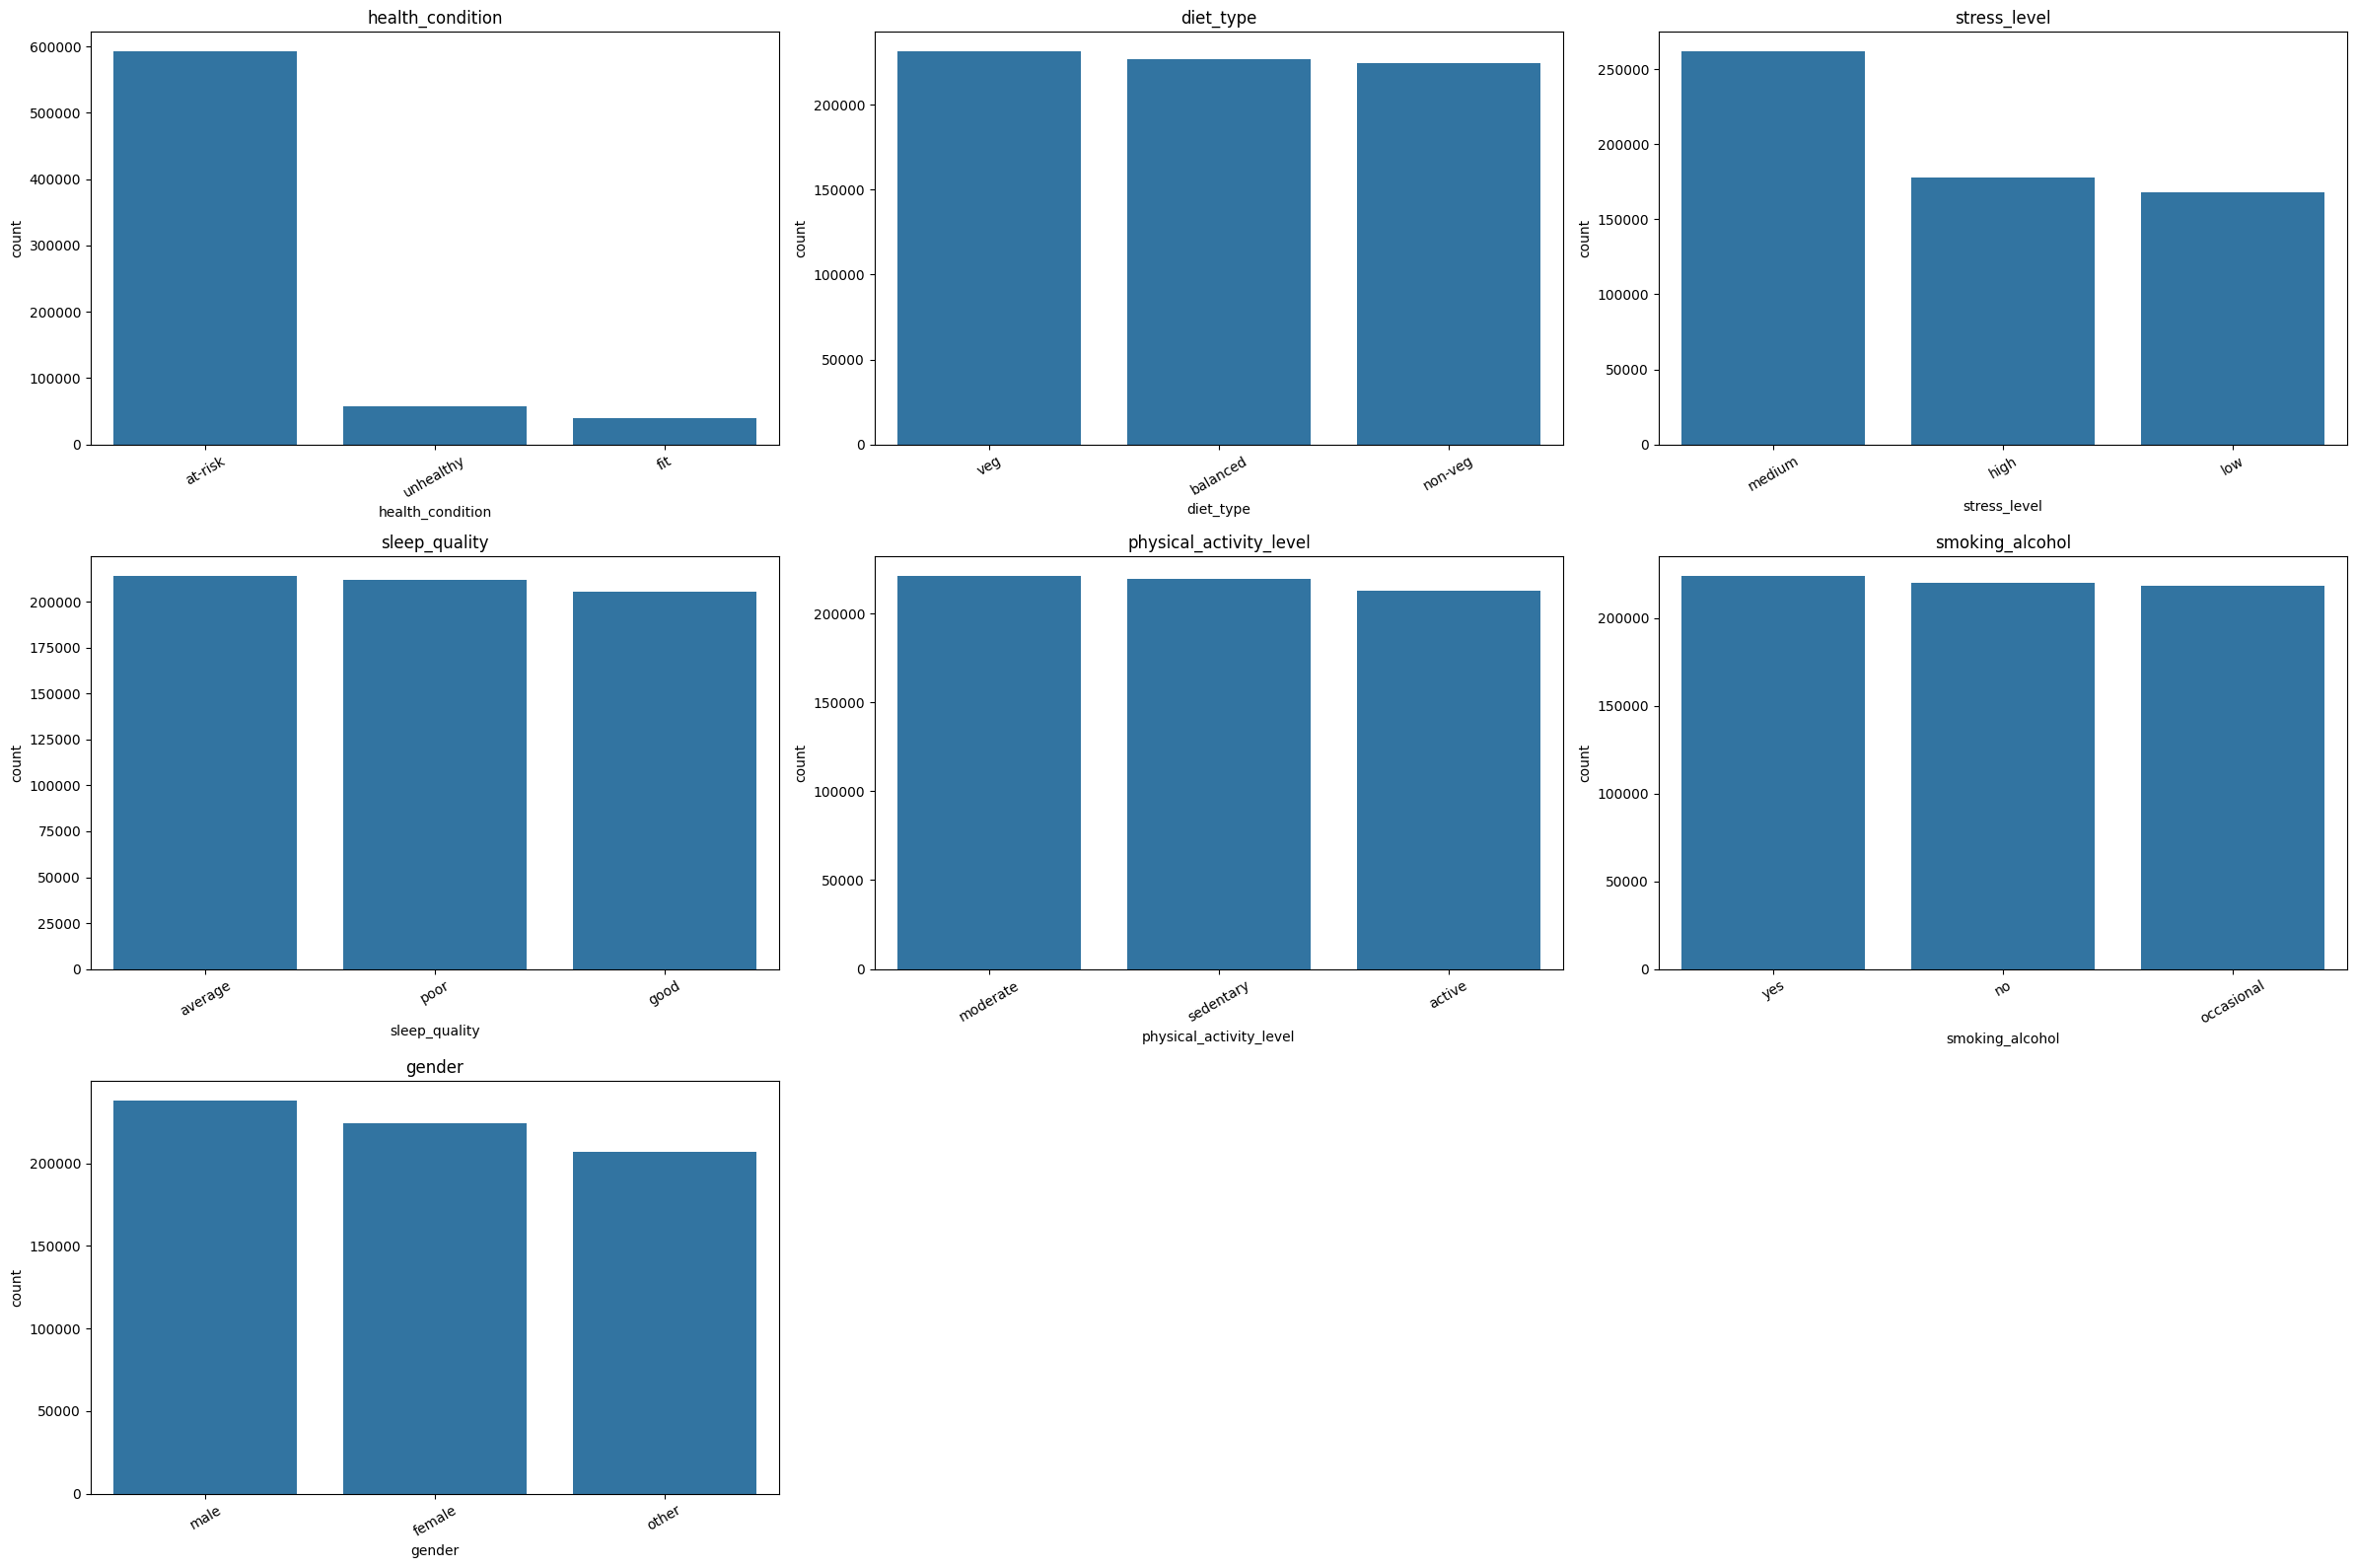

In [18]:
plt.figure(figsize=(24, 16))

for i, col in enumerate(cat_col):
    plt.subplot(3, 3, i + 1)

    sns.countplot(
        data=train,
        x=col,
        order=train[col].value_counts().index
    )

    plt.xticks(rotation=30)
    plt.title(col)

plt.tight_layout()
plt.show()

### Percentage Distribution

In [19]:
for col in cat_col:

    percentage = (train[col].value_counts(normalize=True).mul(100).round(2))

    print(f"\n{col}")
    print(percentage)


health_condition
health_condition
at-risk      85.87
unhealthy     8.36
fit           5.77
Name: proportion, dtype: float64

diet_type
diet_type
veg         33.88
balanced    33.21
non-veg     32.91
Name: proportion, dtype: float64

stress_level
stress_level
medium    43.11
high      29.27
low       27.62
Name: proportion, dtype: float64

sleep_quality
sleep_quality
average    33.87
poor       33.58
good       32.55
Name: proportion, dtype: float64

physical_activity_level
physical_activity_level
moderate     33.83
sedentary    33.63
active       32.54
Name: proportion, dtype: float64

smoking_alcohol
smoking_alcohol
yes           33.82
no            33.23
occasional    32.95
Name: proportion, dtype: float64

gender
gender
male      35.55
female    33.50
other     30.95
Name: proportion, dtype: float64


### Target-wise Analysis
### Relationship Between Categorical Features and Target

• Students with high stress are more likely to belong to unhealthy or at-risk categories.

• Better sleep quality is associated with a higher proportion of fit students.

• Active physical activity levels correspond to healthier outcomes.

• Smoking and alcohol consumption show noticeable differences across health conditions.

• These observations suggest that lifestyle-related categorical variables are strong predictors of health condition.

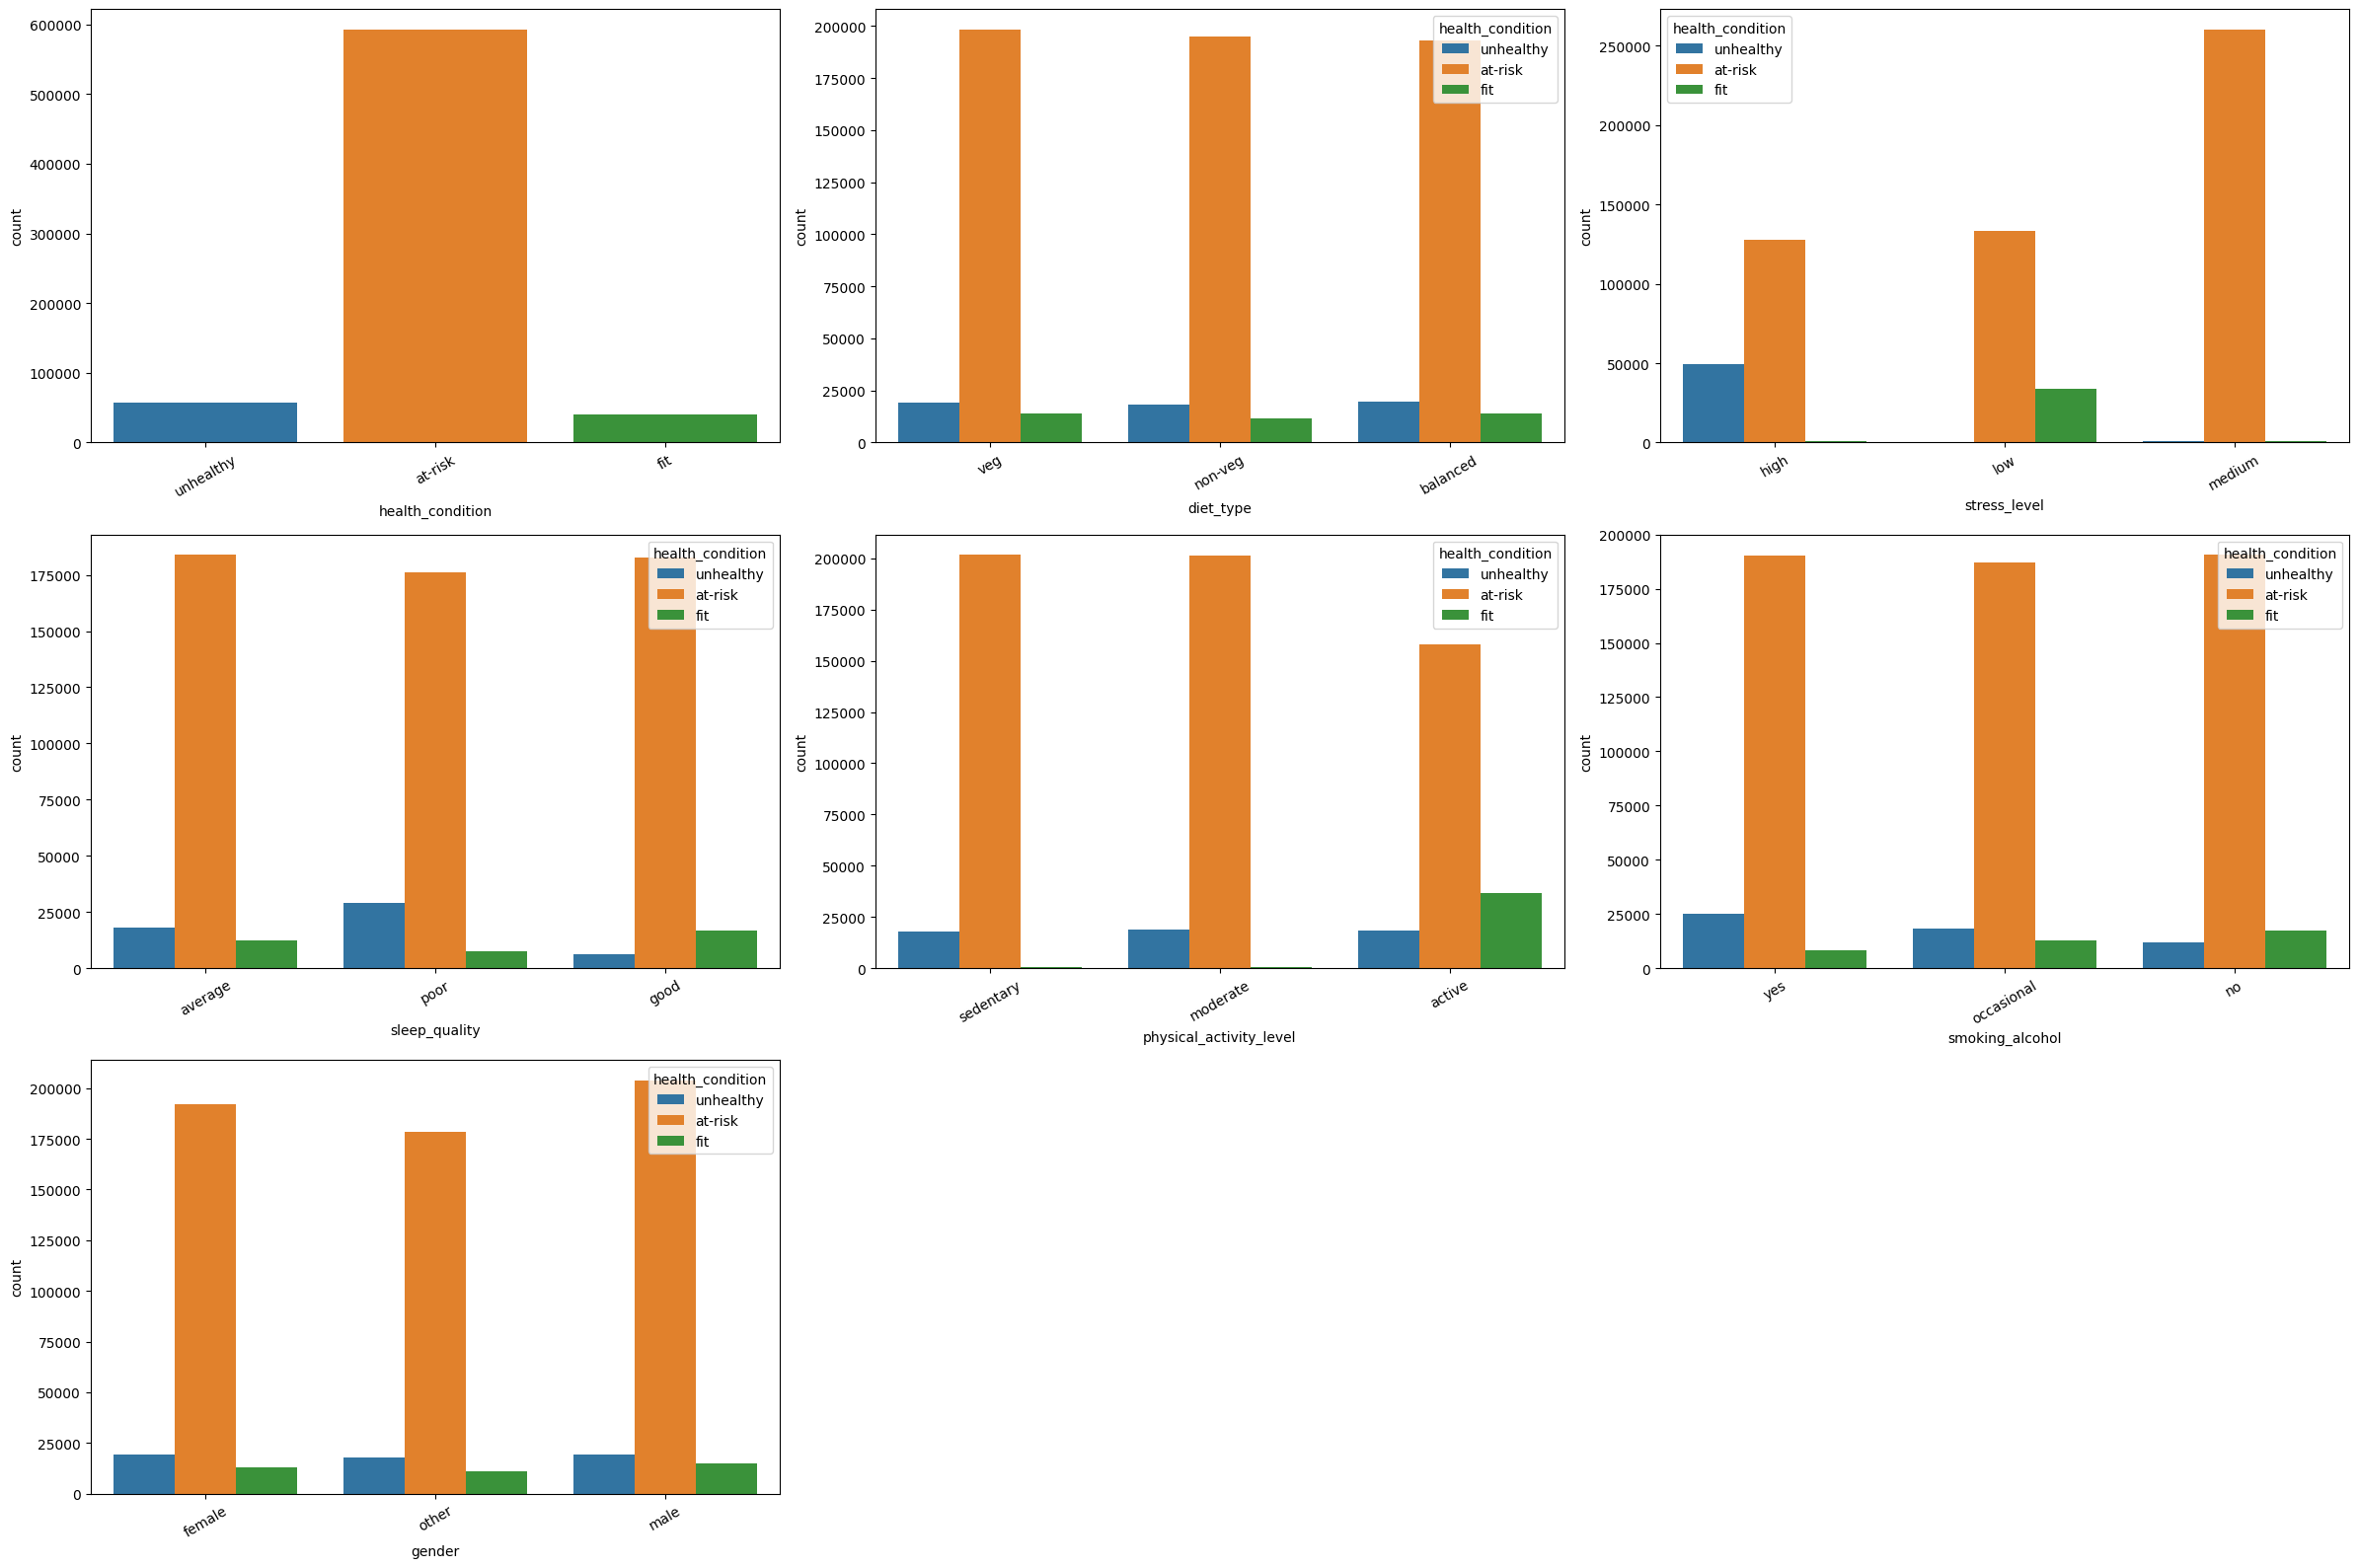

In [20]:
plt.figure(figsize=(24,16))

for i, col in enumerate(cat_col):

    plt.subplot(3,3,i+1)

    sns.countplot(
        data=train,
        x=col,
        hue="health_condition"
    )

    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Stacked Percentage Bar Chart
### Relationship Between Categorical Features and Target

• Students with high stress are more likely to belong to unhealthy or at-risk categories.

• Better sleep quality is associated with a higher proportion of fit students.

• Active physical activity levels correspond to healthier outcomes.

• Smoking and alcohol consumption show noticeable differences across health conditions.

• These observations suggest that lifestyle-related categorical variables are strong predictors of health condition.

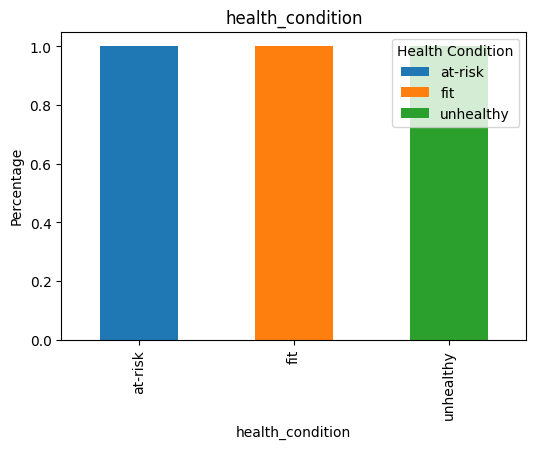

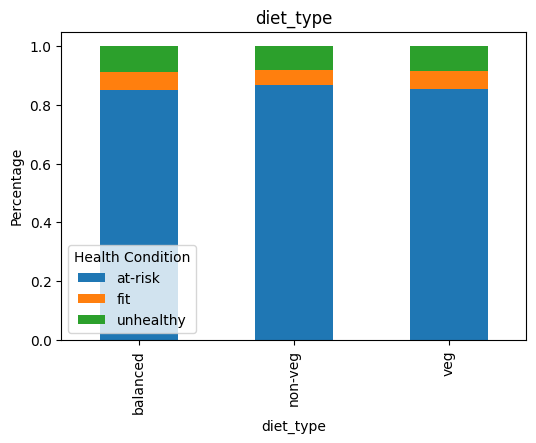

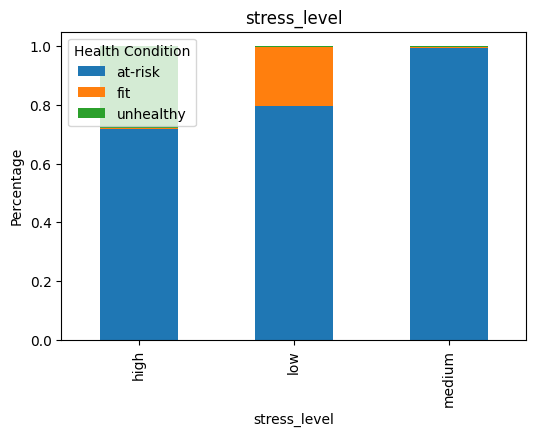

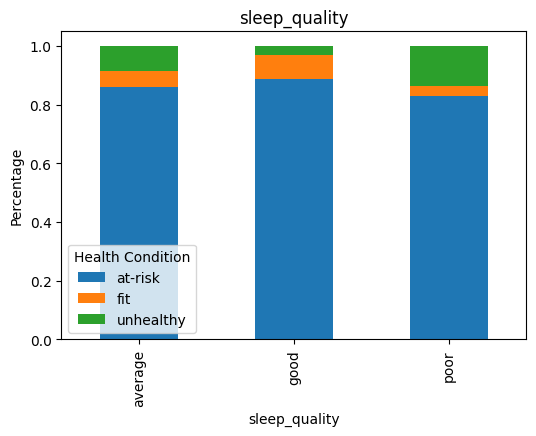

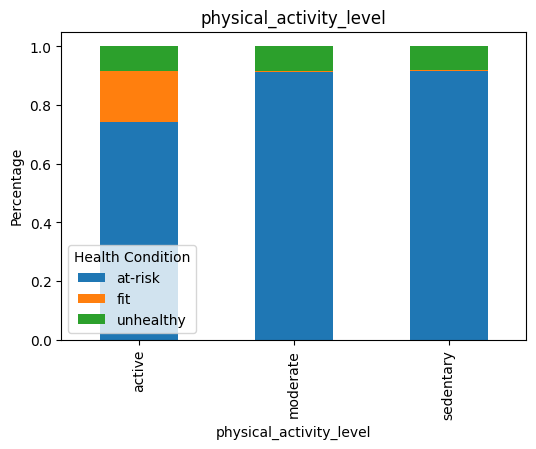

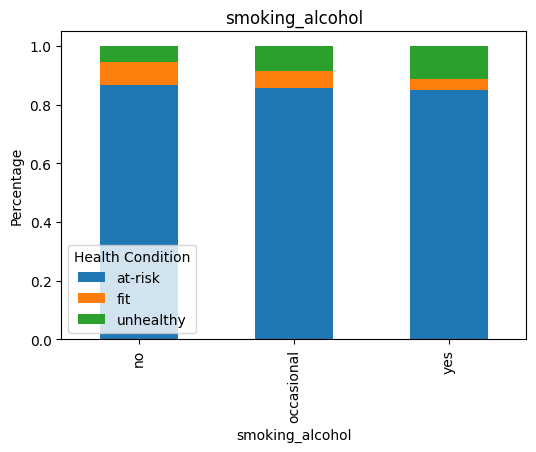

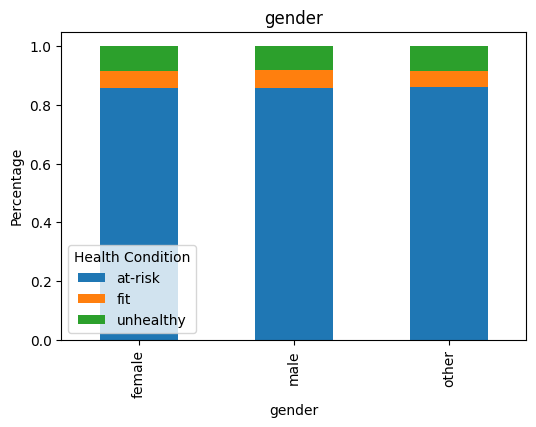

In [21]:
for col in cat_col:

    (
        pd.crosstab(
            train[col],
            train["health_condition"],
            normalize="index"
        )
        .plot(
            kind="bar",
            stacked=True,
            figsize=(6,4)
        )
    )

    plt.title(col)
    plt.ylabel("Percentage")
    plt.legend(title="Health Condition")
    plt.show()

## Correlation Analysis

### Correlation Heatmap

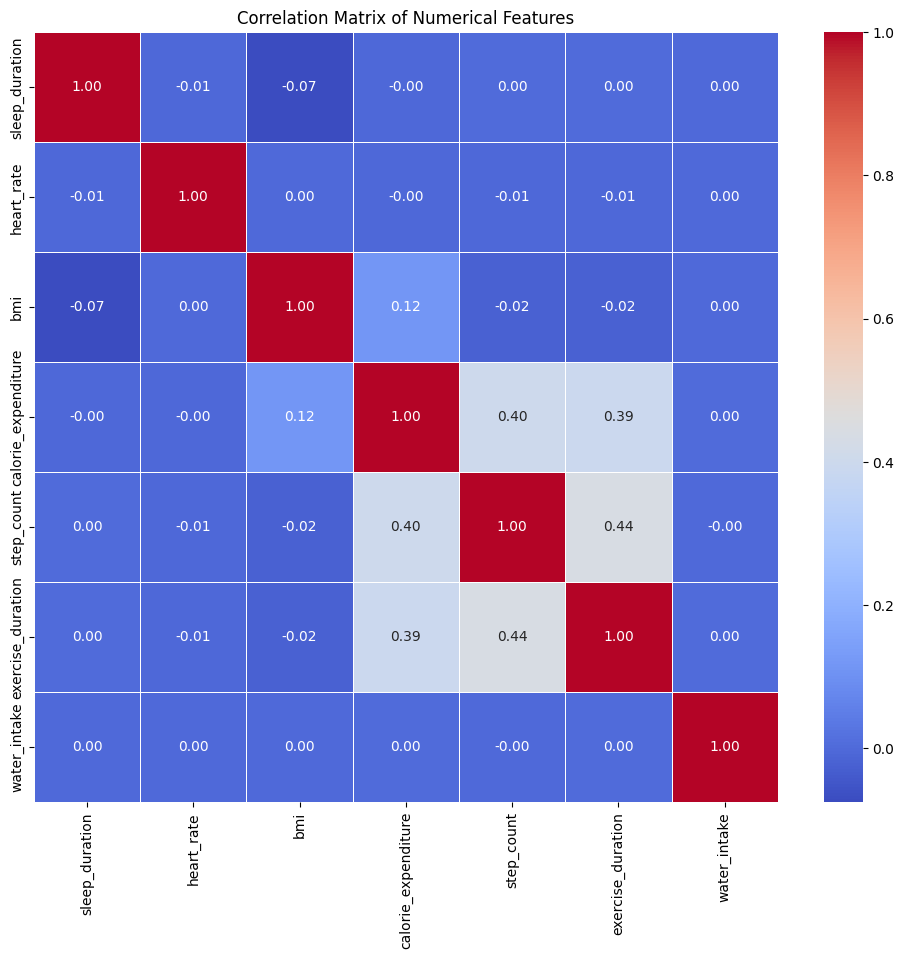

In [22]:
plt.figure(figsize=(12, 10))

corr = train[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Highly Correlated Features

In [23]:
corr_matrix = train[num_cols].corr().abs()

high_corr = (
    corr_matrix
    .where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr.sort_values(
    by="Correlation",
    ascending=False
)

high_corr

,Feature 1,Feature 2,Correlation
18,step_count,exercise_duration,0.438236
15,calorie_expenditure,step_count,0.400102
16,calorie_expenditure,exercise_duration,0.393592
11,bmi,calorie_expenditure,0.117624
1,sleep_duration,bmi,0.074576
12,bmi,step_count,0.020548
13,bmi,exercise_duration,0.020289
9,heart_rate,exercise_duration,0.005679
8,heart_rate,step_count,0.005486
0,sleep_duration,heart_rate,0.005183


### Strong Correlations Only

- There is no strong multicollinearity.

In [24]:
high_corr[
    high_corr["Correlation"] > 0.7
]

,Feature 1,Feature 2,Correlation


# 3. Data Preprocessing / Feature Engineering

## Missing Value Handling

In [25]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

### sleep_duration

In [26]:
train['sleep_duration'].isnull().sum()

np.int64(75999)

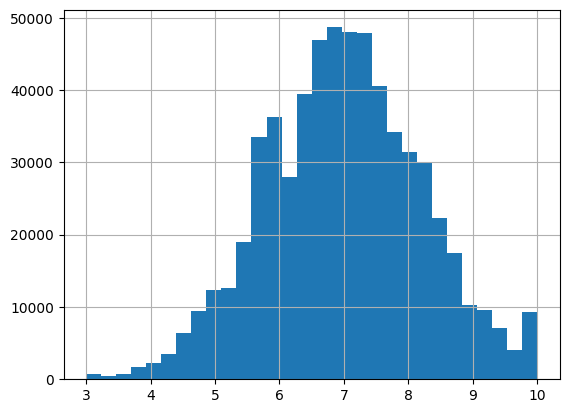

In [27]:
train['sleep_duration'].hist(bins=30)
plt.show()

In [28]:
print(train['sleep_duration'].skew()) 

-0.00823233899896683


In [29]:
# Approximately Normal Distribution -> Fill with mean value
mean_sleep = train["sleep_duration"].mean()

train['sleep_duration'] = train['sleep_duration'].fillna(mean_sleep)
test['sleep_duration'] = test['sleep_duration'].fillna(mean_sleep)

### heart_rate

In [30]:
train['heart_rate'].isnull().sum()

np.int64(7833)

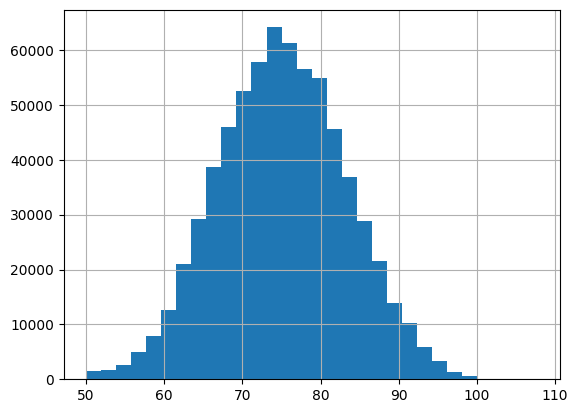

In [31]:
train['heart_rate'].hist(bins=30)
plt.show()

In [32]:
train['heart_rate'].skew()

np.float64(0.0004382013061367681)

In [33]:
# Approximately Normal Distribution -> Fill with mean value
mean_hr = train['heart_rate'].mean()

train['heart_rate'] = train['heart_rate'].fillna(mean_hr)
test['heart_rate'] = test['heart_rate'].fillna(mean_hr)

### bmi

In [34]:
train['bmi'].isnull().sum()

np.int64(13898)

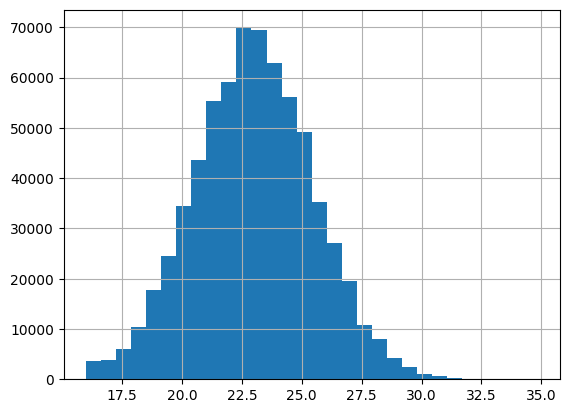

In [35]:
train['bmi'].hist(bins=30)
plt.show()

In [36]:
train['bmi'].skew()

np.float64(0.024639760001979885)

In [37]:
# Approximately Normal Distribution -> Fill with mean value
mean_bmi = train["bmi"].mean()

train["bmi"] = train["bmi"].fillna(mean_bmi)
test["bmi"] = test["bmi"].fillna(mean_bmi)

### calorie_expenditure

In [38]:
train['calorie_expenditure'].isnull().sum()

np.int64(52853)

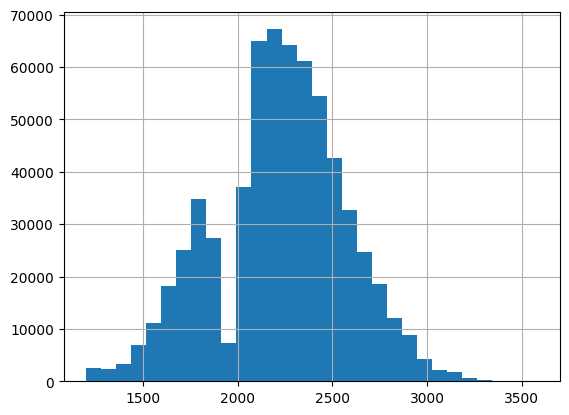

In [39]:
train['calorie_expenditure'].hist(bins=30)
plt.show()

In [40]:
train['calorie_expenditure'].skew()

np.float64(-0.1839399892368627)

In [41]:
# Approximately Normal Distribution -> Fill with mean value
mean_cal = train["calorie_expenditure"].mean()

train["calorie_expenditure"] = train["calorie_expenditure"].fillna(mean_cal)
test["calorie_expenditure"] = test["calorie_expenditure"].fillna(mean_cal)

### step_count

In [42]:
train['step_count'].isnull().sum()

np.int64(13916)

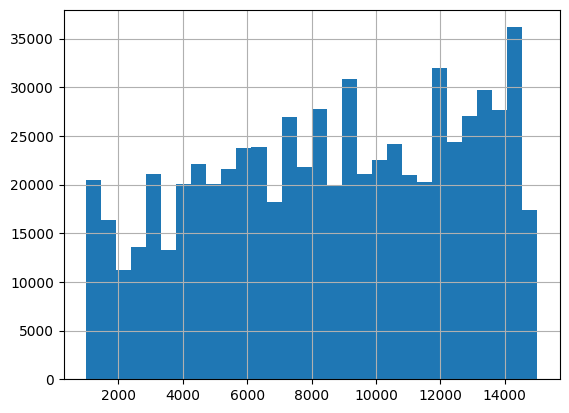

In [43]:
train['step_count'].hist(bins = 30)
plt.show()

In [44]:
train['step_count'].skew()

np.float64(-0.18023843603832704)

In [45]:
# Approximately Normal Distribution -> Fill with mean value
mean_step = train["step_count"].mean()

train["step_count"] = train["step_count"].fillna(mean_step)
test["step_count"] = test["step_count"].fillna(mean_step)

### exercise_duration

In [46]:
train['exercise_duration'].isnull().sum()

np.int64(6901)

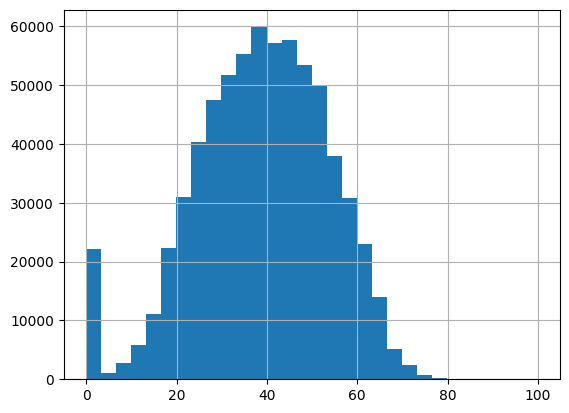

In [47]:
train['exercise_duration'].hist(bins=30)
plt.show()

In [48]:
train['exercise_duration'].skew()

np.float64(-0.3746098024470961)

In [49]:
# Approximately Normal Distribution -> Fill with mean value
mean_exercise = train["exercise_duration"].mean()

train["exercise_duration"] = train["exercise_duration"].fillna(mean_exercise)
test["exercise_duration"] = test["exercise_duration"].fillna(mean_exercise)

### water_intake

In [50]:
train['water_intake'].isnull().sum()

np.int64(43477)

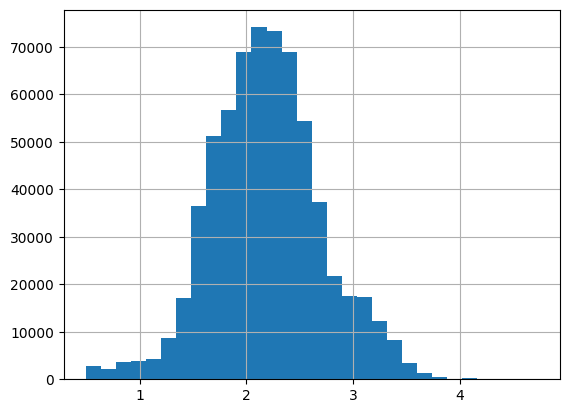

In [51]:
train['water_intake'].hist(bins=30)
plt.show()

In [52]:
train['water_intake'].skew()

np.float64(0.10996029570066149)

In [53]:
# Approximately Normal Distribution -> Fill with mean value
mean_water = train["water_intake"].mean()

train["water_intake"] = train["water_intake"].fillna(mean_water)
test["water_intake"] = test["water_intake"].fillna(mean_water)

### diet_type

In [54]:
train['diet_type'].isnull().sum()

np.int64(6901)

In [55]:
train['diet_type'].value_counts(dropna=False)

diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

In [56]:
# Approximately equally Distribution -> Fill with mode value
mode_diet = train["diet_type"].mode()[0]

train["diet_type"] = train["diet_type"].fillna(mode_diet)
test["diet_type"] = test["diet_type"].fillna(mode_diet)

### stress_level  

In [57]:
train['stress_level'].isnull().sum()

np.int64(82811)

In [58]:
train['stress_level'].value_counts(dropna=False)

stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

In [59]:
# Approximately equally Distribution -> Fill with mode value
mode_stress = train["stress_level"].mode()[0]

train["stress_level"] = train["stress_level"].fillna(mode_stress)
test["stress_level"] = test["stress_level"].fillna(mode_stress)

### sleep_quality

In [60]:
train['sleep_quality'].isnull().sum()

np.int64(58331)

In [61]:
train['sleep_quality'].value_counts(dropna=False)

sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

In [62]:
# Approximately equally Distribution -> Fill with mode value
mode_sleep = train["sleep_quality"].mode()[0]

train["sleep_quality"] = train["sleep_quality"].fillna(mode_sleep)
test["sleep_quality"] = test["sleep_quality"].fillna(mode_sleep)

### physical_activity_level

In [63]:
train['physical_activity_level'].isnull().sum()

np.int64(36621)

In [64]:
train['physical_activity_level'].value_counts(dropna=False)

physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

In [65]:
# Approximately equally Distribution -> Fill with mode value
mode_activity = train["physical_activity_level"].mode()[0]

train["physical_activity_level"] = train["physical_activity_level"].fillna(mode_activity)
test["physical_activity_level"] = test["physical_activity_level"].fillna(mode_activity)

### smoking_alcohol  

In [66]:
train['smoking_alcohol'].isnull().sum()

np.int64(28582)

In [67]:
train['smoking_alcohol'].value_counts(dropna=False)

smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

In [68]:
# Approximately equally Distribution -> Fill with mode value
mode_smoking = train["smoking_alcohol"].mode()[0]

train["smoking_alcohol"] = train["smoking_alcohol"].fillna(mode_smoking)
test["smoking_alcohol"] = test["smoking_alcohol"].fillna(mode_smoking)

### gender

In [69]:
train['gender'].isnull().sum()

np.int64(21373)

In [70]:
train['gender'].value_counts(dropna=False)

gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64

In [71]:
# Approximately equally Distribution -> Fill with mode value
mode_gender = train["gender"].mode()[0]

train["gender"] = train["gender"].fillna(mode_gender)
test["gender"] = test["gender"].fillna(mode_gender)

## Feature Engineering

In [72]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,medium,average,sedentary,yes,male


In [73]:
# Calories burned per step
train["calorie_per_step"] = train["calorie_expenditure"] / train["step_count"]
test["calorie_per_step"] = test["calorie_expenditure"] / test["step_count"]

In [74]:
# Water intake relative to BMI
train["water_per_bmi"] = train["water_intake"] / train["bmi"]
test["water_per_bmi"] = test["water_intake"] / test["bmi"]

In [75]:
# BMI Category
def bmi_category(x):
    if x < 18.5:
        return "Underweight"
    elif x < 25:
        return "Normal"
    elif x < 30:
        return "Overweight"
    else:
        return "Obese"

train["bmi_category"] = train["bmi"].apply(bmi_category)
test["bmi_category"] = test["bmi"].apply(bmi_category)

In [76]:
# Exercise Intensity
train["exercise_intensity"] = train["calorie_expenditure"] / (train["exercise_duration"] + 1)
test["exercise_intensity"] = test["calorie_expenditure"] / (test["exercise_duration"] + 1)

In [77]:
# Steps Per Minutes
train["steps_per_minute"] = train["step_count"] / (train["exercise_duration"] + 1)
test["steps_per_minute"] = test["step_count"] / (test["exercise_duration"] + 1)

## Preprocessing

### Frequency Encoding

In [78]:
numerical_cols = [
    'sleep_duration',
    'heart_rate',
    'bmi',
    'calorie_expenditure',
    'step_count',
    'exercise_duration',
    'water_intake'
]

categorical_cols = [
    'diet_type',
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'smoking_alcohol',
    'gender'
]

full = pd.concat(
    [
        train[numerical_cols + categorical_cols],
        test[numerical_cols + categorical_cols]
    ],
    axis=0,
    ignore_index=True
)

In [79]:
freq_features = []

for col in numerical_cols + categorical_cols:

    freq = full[col].value_counts()

    train[col + "_freq"] = train[col].map(freq)

    test[col + "_freq"] = test[col].map(freq)

    freq_features.append(col + "_freq")

In [80]:
numerical_cols = numerical_cols + freq_features

### Split X and y

In [81]:
# split features and target variable
X = train.drop(columns=["health_condition"])
y = train["health_condition"]

In [82]:
# save id columns
train_id = X["id"]
test_id = test["id"]

X = X.drop(columns=["id"])
test = test.drop(columns=["id"])

In [83]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [84]:
numerical_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake",

    "calorie_per_step",
    "water_per_bmi",
    "exercise_intensity",
    "steps_per_minute",

    "sleep_duration_freq",
    "heart_rate_freq",
    "bmi_freq",
    "calorie_expenditure_freq",
    "step_count_freq",
    "exercise_duration_freq",
    "water_intake_freq",

    "diet_type_freq",
    "stress_level_freq",
    "sleep_quality_freq",
    "physical_activity_level_freq",
    "smoking_alcohol_freq",
    "gender_freq"
]

ordinal_cols = [
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "bmi_category"
]

nominal_cols = [
    "diet_type",
    "smoking_alcohol",
    "gender"
]

In [ ]:
# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["low", "medium", "high"],
                    ["poor", "average", "good"],
                    ["sedentary", "moderate", "active"],
                    ["Underweight", "Normal", "Overweight", "Obese"]
                ]
            ),
            ordinal_cols
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_cols
        )
    ],
    remainder="drop"
)

In [ ]:
# preprocessor1
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_cols
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["low", "medium", "high"],
                    ["poor", "average", "good"],
                    ["sedentary", "moderate", "active"],
                    ["Underweight", "Normal", "Overweight", "Obese"]
                ]
            ),
            ordinal_cols
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_cols
        )
    ],
    remainder="drop"
)

# 4. Model Training

In [86]:
results = []

## Logistic Regression

In [87]:
lr_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train,y_train)

y_pred = lr_pipeline.predict(X_test)

/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_po

In [88]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

results.append({
    "Model": "LogisticRegression",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.35502402183055887
Accuracy : 0.8585039632511702


/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.7664565294859156
Recall   : 0.8585039632511702
F1 Score : 0.800286526571231

Classification Report


/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` param

              precision    recall  f1-score   support

     at-risk       0.86      1.00      0.92    118512
         fit       0.45      0.07      0.12      7961
   unhealthy       0.00      0.00      0.00     11545

    accuracy                           0.86    138018
   macro avg       0.44      0.36      0.35    138018
weighted avg       0.77      0.86      0.80    138018


Confusion Matrix
[[117932    580      0]
 [  7404    557      0]
 [ 11454     91      0]]


/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Decision Tree Classifier

In [89]:
dt_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train,y_train)

y_pred = dt_pipeline.predict(X_test)

In [90]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

results.append({
    "Model": "Decision Tree",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8507845646370212
Accuracy : 0.9378776681302439
Precision: 0.9389792915229419
Recall   : 0.9378776681302439
F1 Score : 0.9383798512773334

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      0.96      0.96    118512
         fit       0.76      0.79      0.77      7961
   unhealthy       0.77      0.80      0.79     11545

    accuracy                           0.94    138018
   macro avg       0.83      0.85      0.84    138018
weighted avg       0.94      0.94      0.94    138018


Confusion Matrix
[[113907   1958   2647]
 [  1597   6294     70]
 [  2252     50   9243]]


## Random Forest Classifier

In [91]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)


In [92]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

results.append({
    "Model": "Random Forest",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8536838490371047
Accuracy          : 0.9651857004158878
Precision         : 0.9651711617643962
Recall            : 0.9651857004158878
F1 Score          : 0.9636006149075557

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      1.00      0.98    118512
         fit       0.95      0.79      0.87      7961
   unhealthy       0.97      0.77      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.85      0.90    138018
weighted avg       0.97      0.97      0.96    138018


Confusion Matrix
[[117986    286    240]
 [  1609   6323     29]
 [  2625     16   8904]]


## Extra Tree Classifier

In [93]:
et_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

et_pipeline.fit(X_train, y_train)

y_pred = et_pipeline.predict(X_test)

In [94]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

results.append({
    "Model": "Extra Trees",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8429269101121423
Accuracy          : 0.9617658566273964
Precision         : 0.9615239687201301
Recall            : 0.9617658566273964
F1 Score          : 0.9599698122935548

Classification Report
              precision    recall  f1-score   support

     at-risk       0.96      0.99      0.98    118512
         fit       0.94      0.78      0.85      7961
   unhealthy       0.96      0.76      0.85     11545

    accuracy                           0.96    138018
   macro avg       0.95      0.84      0.89    138018
weighted avg       0.96      0.96      0.96    138018


Confusion Matrix
[[117808    397    307]
 [  1749   6187     25]
 [  2784     15   8746]]


## LightGBM

In [ ]:
lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor1),
    ("classifier", LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

lgbm_pipeline.fit(X_train, y_train)

y_pred = lgbm_pipeline.predict(X_test)

/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [96]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

results.append({
    "Model": "LightGBM",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8581434837344144
Accuracy          : 0.9658015621150864
Precision         : 0.9656854969973194
Recall            : 0.9658015621150864
F1 Score          : 0.9643418210448393

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      1.00      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.97      0.78      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018


Confusion Matrix
[[117927    317    268]
 [  1576   6359     26]
 [  2518     15   9012]]


## CatBoost

In [ ]:
cat_pipeline = Pipeline([
    ("preprocessor", preprocessor1),
    ("classifier", CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

cat_pipeline.fit(X_train, y_train)

y_pred = cat_pipeline.predict(X_test)


In [98]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

results.append({
    "Model": "CatBoost",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8587566661526912
Accuracy          : 0.9656349171847151
Precision         : 0.9654265328898496
Recall            : 0.9656349171847151
F1 Score          : 0.9642090242834124

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.96      0.78      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018


Confusion Matrix
[[117873    324    315]
 [  1585   6349     27]
 [  2477     15   9053]]


## XGBoost

In [99]:
le = LabelEncoder()
y_encoded = le.fit_transform(train["health_condition"])

X = train.drop(columns=["health_condition"])

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
preprocessor1 = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_cols
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["low", "medium", "high"],
                    ["poor", "average", "good"],
                    ["sedentary", "moderate", "active"],
                    ["Underweight", "Normal", "Overweight", "Obese"]
                ]
            ),
            ordinal_cols
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_cols
        )

    ]
)

In [ ]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor1),
    ("classifier", XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)


In [103]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred)
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

results.append({
    "Model": "XGBoost",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8594313656401497
Accuracy          : 0.9658957527279051
Precision         : 0.9656983347278341
Recall            : 0.9658957527279051
F1 Score          : 0.9644864517401266

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.96      0.79      0.87     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018


Confusion Matrix
[[117885    306    321]
 [  1590   6345     26]
 [  2449     15   9081]]


# 5. Model Selection

### Model Comparision Analysis
Seven machine learning models were evaluated using Balanced Accuracy, Accuracy, Precision, Recall, F1 Score, and Macro F1.

Among all baseline models, XGBoost achieved the highest Balanced Accuracy (0.8594), followed closely by CatBoost (0.8588) and LightGBM (0.8581).

The ensemble boosting algorithms consistently outperformed traditional machine learning models such as Logistic Regression and Decision Tree, indicating that the dataset contains complex non-linear relationships.

Based on the evaluation metrics, XGBoost was selected as the final model for further hyperparameter tuning using Optuna.

In [104]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="Balanced Accuracy", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score,Macro F1
0,XGBoost,0.859431,0.965896,0.965698,0.965896,0.964486,0.904713
1,CatBoost,0.858757,0.965635,0.965427,0.965635,0.964209,0.903976
2,LightGBM,0.858143,0.965802,0.965685,0.965802,0.964342,0.904324
3,Random Forest,0.853684,0.965186,0.965171,0.965186,0.963601,0.902255
4,Decision Tree,0.850785,0.937878,0.938979,0.937878,0.938380,0.841572
5,Extra Trees,0.842927,0.961766,0.961524,0.961766,0.959970,0.892099
6,LogisticRegression,0.355024,0.858504,0.766457,0.858504,0.800287,0.348365


# 6. Hyperparameter tuning using optuna

In [105]:
final_result = []

## XGBoost

In [106]:
def objective(trial):

    params = {

        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",

        "random_state": 42,
        "n_jobs": -1,

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            10
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            10
        )
    }

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(**params))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    score = balanced_accuracy_score(y_test, y_pred)

    return score

In [107]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-07-10 09:15:24,417] A new study created in memory with name: no-name-c81d2163-8cc5-4479-9096-f8101a17e6a8
Best trial: 0. Best value: 0.859248:   2%|▏         | 1/50 [00:21<17:36, 21.55s/it]

[I 2026-07-10 09:15:45,970] Trial 0 finished with value: 0.8592480038996196 and parameters: {'n_estimators': 500, 'learning_rate': 0.2536999076681771, 'max_depth': 10, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.8592480038996196.


Best trial: 0. Best value: 0.859248:   4%|▍         | 2/50 [00:58<24:30, 30.64s/it]

[I 2026-07-10 09:16:22,969] Trial 1 finished with value: 0.8581496792403297 and parameters: {'n_estimators': 767, 'learning_rate': 0.010725209743171997, 'max_depth': 12, 'min_child_weight': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.9170225492671691, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 0.8592480038996196.


Best trial: 0. Best value: 0.859248:   6%|▌         | 3/50 [01:18<20:10, 25.76s/it]

...

[I 2026-07-10 09:35:54,327] Trial 47 finished with value: 0.8582854161075247 and parameters: {'n_estimators': 409, 'learning_rate': 0.036764281610919, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.655249280363061, 'colsample_bytree': 0.7375307198497826, 'gamma': 1.2203492997583345, 'reg_alpha': 5.487534168997471, 'reg_lambda': 3.2036938454112107}. Best is trial 23 with value: 0.8608484020026238.


Best trial: 23. Best value: 0.860848:  98%|█████████▊| 49/50 [20:51<00:28, 28.55s/it]

[I 2026-07-10 09:36:16,111] Trial 48 finished with value: 0.8585686896024954 and parameters: {'n_estimators': 671, 'learning_rate': 0.07706342100151237, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.7911219990202718, 'colsample_bytree': 0.8707075467647747, 'gamma': 1.7056977323868006, 'reg_alpha': 6.219944553740811, 'reg_lambda': 2.440031062132447}. Best is trial 23 with value: 0.8608484020026238.


Best trial: 23. Best value: 0.860848: 100%|██████████| 50/50 [21:19<00:00, 25.59s/it]

[I 2026-07-10 09:36:43,849] Trial 49 finished with value: 0.8595915249115557 and parameters: {'n_estimators': 868, 'learning_rate': 0.11561457547227869, 'max_depth': 3, 'min_child_weight': 4, 'subsample': 0.7594749641827846, 'colsample_bytree': 0.8982172465383216, 'gamma': 0.8435787428998365, 'reg_alpha': 2.014985558043617, 'reg_lambda': 4.424648652851726}. Best is trial 23 with value: 0.8608484020026238.


In [108]:
print("Best Balanced Accuracy:")
print(study.best_value)

print("Best Parameters:\n")

for key, value in study.best_params.items():
    print(f"{key} : {value}")

Best Balanced Accuracy:
0.8608484020026238
Best Parameters:

n_estimators : 901
learning_rate : 0.1269226035706435
max_depth : 7
min_child_weight : 2
subsample : 0.8536311617031827
colsample_bytree : 0.786594227183789
gamma : 0.5836320024400756
reg_alpha : 6.407959798881424
reg_lambda : 5.095832901344782


In [109]:
best_xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(

        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",

        random_state=42,
        n_jobs=-1,

        **study.best_params
     ))
])

best_xgb_pipeline.fit(X_train, y_train)

y_pred = best_xgb_pipeline.predict(X_test)

In [110]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred)
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

final_result.append({
    "Model": "XGBoost Tuned",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8608484020026238
Accuracy          : 0.9657870712515759
Precision         : 0.965490280816028
Recall            : 0.9657870712515759
F1 Score          : 0.9644303186755271

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.96      0.79      0.87     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018


Confusion Matrix
[[117816    323    373]
 [  1586   6349     26]
 [  2400     14   9131]]


## LGBM

In [111]:
def objective(trial):

    params = {

        "objective": "multiclass",

        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            1000
            
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            300
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            15
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            10
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            10
        )
    }

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(**params))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    return balanced_accuracy_score(y_test, y_pred)

In [112]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-07-10 09:37:17,103] A new study created in memory with name: no-name-efd81a07-3b47-4b4e-9954-bfc8d8f4558f
  0%|          | 0/20 [00:00<?, ?it/s]/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.860546:   5%|▌         | 1/20 [01:07<21:19, 67.35s/it]

[I 2026-07-10 09:38:24,457] Trial 0 finished with value: 0.8605459937732505 and parameters: {'n_estimators': 500, 'learning_rate': 0.2536999076681771, 'num_leaves': 225, 'max_depth': 10, 'min_child_samples': 19, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.8605459937732505.


/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.860546:  10%|█         | 2/20 [03:35<34:31, 115.08s/it]

[I 2026-07-10 09:40:52,936] Trial 1 finished with value: 0.8587311787339624 and parameters: {'n_estimators': 767, 'learning_rate': 0.010725209743171997, 'num_leaves': 292, 'max_depth': 13, 'min_child_samples': 25, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 0.8605459937732505.


/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.860546:  15%|█▌        | 3/20 [03:54<20:06, 70.97s/it] 

...

[I 2026-07-10 09:52:16,366] Trial 17 finished with value: 0.8595007860038132 and parameters: {'n_estimators': 667, 'learning_rate': 0.05999513857106563, 'num_leaves': 62, 'max_depth': 15, 'min_child_samples': 65, 'subsample': 0.9150447742588977, 'colsample_bytree': 0.9054590403541816, 'reg_alpha': 3.3151131836991716, 'reg_lambda': 3.7372018289699867}. Best is trial 6 with value: 0.8607716932902753.


/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 6. Best value: 0.860772:  95%|█████████▌| 19/20 [16:25<01:06, 66.65s/it]

[I 2026-07-10 09:53:42,582] Trial 18 finished with value: 0.8587859588540973 and parameters: {'n_estimators': 870, 'learning_rate': 0.12965512183731948, 'num_leaves': 135, 'max_depth': 13, 'min_child_samples': 71, 'subsample': 0.7888490300704193, 'colsample_bytree': 0.8560895926246929, 'reg_alpha': 1.533939334508973, 'reg_lambda': 0.44084778807131686}. Best is trial 6 with value: 0.8607716932902753.


/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 6. Best value: 0.860772: 100%|██████████| 20/20 [16:47<00:00, 50.40s/it]

[I 2026-07-10 09:54:05,090] Trial 19 finished with value: 0.8605889716839736 and parameters: {'n_estimators': 571, 'learning_rate': 0.20306537605843702, 'num_leaves': 256, 'max_depth': 5, 'min_child_samples': 97, 'subsample': 0.7093005494078926, 'colsample_bytree': 0.9340092452403835, 'reg_alpha': 3.998584518661312, 'reg_lambda': 3.842851246054508}. Best is trial 6 with value: 0.8607716932902753.


In [113]:
print("Best Balanced Accuracy:")
print(study.best_value)

print("Best Parameters:\n")

for key, value in study.best_params.items():
    print(f"{key} : {value}")

Best Balanced Accuracy:
0.8607716932902753
Best Parameters:

n_estimators : 678
learning_rate : 0.22999586428143734
num_leaves : 44
max_depth : 5
min_child_samples : 9
subsample : 0.7301321323053057
colsample_bytree : 0.7554709158757927
reg_alpha : 2.713490317738959
reg_lambda : 8.287375091519294


In [114]:
best_lgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LGBMClassifier(
        objective="multiclass",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **study.best_params
     ))
])

best_lgb_pipeline.fit(X_train, y_train)

y_pred = best_lgb_pipeline.predict(X_test)

/Users/MANDANI/Desktop/ARNAV/Health-Condition-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [115]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

final_result.append({
    "Model": "LightGBM Tuned",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.8607716932902753
Accuracy          : 0.9652871364604617
Precision         : 0.9648893866794228
Recall            : 0.9652871364604617
F1 Score          : 0.963948593485622

Classification Report
              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.95      0.79      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.96      0.97      0.96    138018


Confusion Matrix
[[117741    347    424]
 [  1587   6346     28]
 [  2390     15   9140]]


## CatBoost

In [116]:
def objective(trial):

    params = {

        "loss_function": "MultiClass",

        "random_state": 42,
        "verbose": 0,

        "iterations": trial.suggest_int(
            "iterations",
            200,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            10
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            10
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            10
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            255
        ),

        "auto_class_weights": "Balanced"
    }

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", CatBoostClassifier(**params))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    return balanced_accuracy_score(y_test, y_pred)

In [117]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-07-10 09:54:30,988] A new study created in memory with name: no-name-2af22548-ded6-4d21-826a-d04682a050d0
Best trial: 0. Best value: 0.894874:   5%|▌         | 1/20 [01:21<25:48, 81.53s/it]

[I 2026-07-10 09:55:52,513] Trial 0 finished with value: 0.8948737506932279 and parameters: {'iterations': 500, 'learning_rate': 0.2536999076681771, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'random_strength': 1.5601864044243652, 'bagging_temperature': 1.5599452033620265, 'border_count': 45}. Best is trial 0 with value: 0.8948737506932279.


Best trial: 1. Best value: 0.902529:  10%|█         | 2/20 [03:30<32:47, 109.28s/it]

[I 2026-07-10 09:58:01,230] Trial 1 finished with value: 0.9025289824922194 and parameters: {'iterations': 893, 'learning_rate': 0.07725378389307355, 'depth': 8, 'l2_leaf_reg': 1.185260448662222, 'random_strength': 9.699098521619943, 'bagging_temperature': 8.324426408004218, 'border_count': 79}. Best is trial 1 with value: 0.9025289824922194.


Best trial: 2. Best value: 0.905691:  15%|█▌        | 3/20 [03:53<19:48, 69.91s/it] 

...

[I 2026-07-10 10:11:55,757] Trial 17 finished with value: 0.9071533613633473 and parameters: {'iterations': 920, 'learning_rate': 0.03886253172452681, 'depth': 5, 'l2_leaf_reg': 8.604690639055596, 'random_strength': 7.020241990115883, 'bagging_temperature': 2.5542567131665073, 'border_count': 58}. Best is trial 15 with value: 0.9102492497027148.


Best trial: 15. Best value: 0.910249:  95%|█████████▌| 19/20 [18:03<00:49, 49.15s/it]

[I 2026-07-10 10:12:34,501] Trial 18 finished with value: 0.9085991222975567 and parameters: {'iterations': 684, 'learning_rate': 0.043978458139766696, 'depth': 5, 'l2_leaf_reg': 8.73684887675996, 'random_strength': 5.25133135882793, 'bagging_temperature': 1.2064436435587642, 'border_count': 119}. Best is trial 15 with value: 0.9102492497027148.


Best trial: 15. Best value: 0.910249: 100%|██████████| 20/20 [18:43<00:00, 56.16s/it]

[I 2026-07-10 10:13:14,158] Trial 19 finished with value: 0.905418744205627 and parameters: {'iterations': 561, 'learning_rate': 0.010519672653182946, 'depth': 7, 'l2_leaf_reg': 5.374396306492875, 'random_strength': 7.098970316461414, 'bagging_temperature': 3.7734415134720214, 'border_count': 81}. Best is trial 15 with value: 0.9102492497027148.


In [118]:
print("Best Balanced Accuracy:")
print(study.best_value)

print("Best Parameters:\n")

for key, value in study.best_params.items():
    print(f"{key} : {value}")

Best Balanced Accuracy:
0.9102492497027148
Best Parameters:

iterations : 999
learning_rate : 0.044322327847781104
depth : 5
l2_leaf_reg : 8.5095675326463
random_strength : 6.033920256408444
bagging_temperature : 0.30332938672576826
border_count : 103


In [119]:
best_cat_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     CatBoostClassifier(
        loss_function="MultiClass",
        random_state=42,
        verbose=0,
        auto_class_weights="Balanced",
        **study.best_params
     ))
])

best_cat_pipeline.fit(X_train, y_train)

y_pred = best_cat_pipeline.predict(X_test)

In [120]:
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_pred))
print("Accuracy          :", accuracy_score(y_test, y_pred))
print("Precision         :", precision_score(y_test, y_pred, average="weighted"))
print("Recall            :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score          :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

final_result.append({
    "Model": "CatBoost Tuned",
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    "Macro F1": f1_score(y_test, y_pred, average="macro")
})

Balanced Accuracy : 0.9102492497027148
Accuracy          : 0.8810589923053515
Precision         : 0.9254636431840518
Recall            : 0.8810589923053515
F1 Score          : 0.8931125623911313

Classification Report
              precision    recall  f1-score   support

     at-risk       0.99      0.87      0.93    118512
         fit       0.51      0.92      0.66      7961
   unhealthy       0.57      0.94      0.71     11545

    accuracy                           0.88    138018
   macro avg       0.69      0.91      0.76    138018
weighted avg       0.93      0.88      0.89    138018


Confusion Matrix
[[103454   6928   8130]
 [   579   7331     51]
 [   691     37  10817]]


# 7. Final Model


## Conclusion

- Compared seven machine learning models.
- Performed feature engineering and frequency encoding.
- Used Optuna for hyperparameter tuning.
- Selected CatBoost as the final model.
- Achieved a Kaggle Public Leaderboard score of **0.90625**.
- Saved the final pipeline and deployed it with Streamlit.

In [121]:
final_result_df = (
    pd.DataFrame(final_result)
    .sort_values(by="Balanced Accuracy", ascending=False)
    .reset_index(drop=True)
)

final_result_df

,Model,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score,Macro F1
0,CatBoost Tuned,0.910249,0.881059,0.925464,0.881059,0.893113,0.764643
1,XGBoost Tuned,0.860848,0.965787,0.965490,0.965787,0.964430,0.904659
2,LightGBM Tuned,0.860772,0.965287,0.964889,0.965287,0.963949,0.903432


In [122]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        **study.best_params,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_state=42,
        verbose=0
    ))
])

best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['sleep_duration',
                                                   'heart_rate', 'bmi',
                                                   'calorie_expenditure',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake',
                                                   'calorie_per_step',
                                                   'water_per_bmi',
                                                   'exercise_intensity',
                                                   'steps_per_minute',
                                                   'sleep_duration_freq',
                                                   'heart_rate_freq',
                                                   'bmi_freq',
                                                   'calorie_expenditure_freq',
                                                   'step...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['diet_type',
                                                   'smoking_alcohol',
                                                   'gender'])])),
                ('classifier',
                 CatBoostClassifier(auto_class_weights='Balanced', bagging_temperature=0.30332938672576826, border_count=103, depth=5, iterations=999, l2_leaf_reg=8.5095675326463, learning_rate=0.044322327847781104, loss_function='MultiClass', random_state=42, random_strength=6.033920256408444, verbose=0))])

In [123]:
y_pred_final = best_model.predict(test)

In [124]:
y_pred_final = y_pred_final.ravel()

In [125]:
submission = pd.DataFrame({
    "id": test_id,
    "health_condition": y_pred_final
})

In [126]:
submission.to_csv("submission.csv", index=False)

# 8. Save Final Model

In [127]:
import pickle

with open("health_condition_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [128]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [129]:
freq_maps = {}

freq_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake",
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in freq_cols:
    freq_maps[col] = train[col].value_counts().to_dict()

with open("frequency_maps.pkl", "wb") as f:
    pickle.dump(freq_maps, f)